# Meta-optimisers

Every optimiser so far produces weights by solving *one* problem. **Meta-optimisers** instead
orchestrate *other* optimisers: they split the problem up, solve the pieces with whatever
estimator you like, and recombine the results. They are the package's answer to two practical
worries — estimation error (a single fit on all assets is fragile) and modularity (you may
want different rules for different parts of the universe).

`PortfolioOptimisers` provides three, all sharing the same inner/outer composition idea:

  - `NestedClustered` (NCO) — cluster the assets, run an **inner** optimiser inside
    each cluster, then an **outer** optimiser across the cluster aggregates.
  - `Stacking` — run several inner optimisers on the **full** universe, then stack
    their portfolios together with an outer optimiser (an ensemble).
  - `SubsetResampling` — repeatedly optimise on random **subsets** of the assets and
    average the resampled weights, à la bagging.

Because the inner and outer slots accept *any* optimisation estimator (including other
meta-optimisers), these compose arbitrarily.

> **When to reach for this**
>
> Reach for a meta-optimiser when a single global fit feels too fragile or too monolithic:
> NCO when you trust the cluster structure and want a different rule within vs across groups,
> Stacking when you want to hedge model risk by ensembling several optimisers, and
> SubsetResampling when you want bagging-style robustness against the specific asset set and
> estimation noise. If a single optimiser already does what you need, prefer it — these add
> compute and configuration surface in exchange for robustness.

In [1]:
using PortfolioOptimisers, PrettyTables, StableRNGs

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data and shared ingredients

We use the same S&P 500 slice as the other optimiser examples, and precompute a prior, a
clustering, and a solver to share across the meta-optimisers.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
pr = prior(EmpiricalPrior(), rd)
clr = clusterise(ClustersEstimator(; alg = DBHT()), pr.X)

Clusters
  res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
    S ┼ 20×20 Matrix{Float64}
    D ┼ 20×20 Matrix{Float64}
    P ┼ nothing
    k ┴ Int64: 4


A recurring pattern below illustrates the **precomputed-result vs estimator** distinction (see
the [`MeanRisk` objectives](01_MeanRisk_Objectives.md) note). The **inner** optimiser is given
the precomputed prior through its `JuMPOptimiser` (`pe = pr`) — fine, because the inner
solves run on the real asset returns. The **outer** optimiser is deliberately *not* given a
prior: it operates on the synthetic per-cluster (or stacked) returns the meta-optimiser builds
internally, where a precomputed asset-level prior would be meaningless. The outer slot is an
estimator-driven slot — it recomputes whatever statistics it needs from those synthetic returns
at solve time, so here it only needs a solver. (Passing `pe = pr` to the *outer* optimiser would
silently feed it the wrong, asset-level prior.)

In [3]:
jopti = JuMPOptimiser(; pe = pr, slv = slv)
jopto = JuMPOptimiser(; slv = slv)

JuMPOptimiser
       pe ┼ EmpiricalPrior
          │        ce ┼ PortfolioOptimisersCovariance
          │           │   ce ┼ Covariance
          │           │      │    me ┼ SimpleExpectedReturns
          │           │      │       │   w ┴ nothing
          │           │      │    ce ┼ GeneralCovariance
          │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
          │           │      │       │    w ┴ nothing
          │           │      │   alg ┴ FullMoment()
          │           │   mp ┼ MatrixProcessing
          │           │      │     pdm ┼ Posdef
          │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
          │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
          │           │      │      dn ┼ nothing
          │           │      │      dt ┼ nothing
          │           │      │     alg ┼ nothing
          │           │      │   order ┴ NTuple{4, Symbol}: (:pdm, :dn, :dt, :alg)

For a reference point we also compute a plain minimum-variance `MeanRisk` over the
whole universe.

In [4]:
res_bench = optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

## 2. Nested clustered optimisation (NCO)

NCO solves a minimum-variance problem *inside* each cluster, collapses each cluster to a
single synthetic asset, then solves a second minimum-variance problem *across* the clusters.
The inner and outer optimisers are independent — here both are `MeanRisk`, but either
could be a risk-budgeting, hierarchical, or naive estimator.

In [5]:
res_nco = optimise(NestedClustered(; pe = pr, cle = clr,
                                   opti = MeanRisk(; obj = MinimumRisk(), opt = jopti),
                                   opto = MeanRisk(; obj = MinimumRisk(), opt = jopto)), rd)

NestedClusteredResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
          │     S ┼ 20×20 Matrix{Float64}
          │     D ┼ 20×20 Matrix{Float64}
          

## 3. Stacking

Stacking runs a *list* of inner optimisers on the full universe — here a min-variance
`MeanRisk`, a `HierarchicalRiskParity`, and a naive `InverseVolatility`
— then combines their portfolios with an outer optimiser. The result is an ensemble that
hedges the model risk of any single rule.

In [6]:
res_stk = optimise(Stacking(; pe = pr,
                            opti = [MeanRisk(; opt = jopti),
                                    HierarchicalRiskParity(;
                                                           opt = HierarchicalOptimiser(;
                                                                                       pe = pr)),
                                    InverseVolatility(; pe = pr)],
                            opto = MeanRisk(; obj = MinimumRisk(), opt = jopto)), rd)

StackingResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
       wb ┼ WeightBounds
          │   lb ┼ Vector{Float64}: [-Inf, -Inf, -Inf]
          │   ub ┴ Vector{Float64}: [Inf, Inf, Inf]
     fees ┼ nothing
     resi ┼ 3-element Vector{NonFiniteAllocationOptimisationResult}
          │ MeanRiskResult ⋯
          │ HierarchicalResult ⋯
          │ NaiveOptimisationResult ⋯
     reso ┼ MeanRiskResult
          │   jr ┼ JuMPOptimisationResult
          │      │        oe ┼ DataType: DataType
          │      │        pa ┼ ProcessedJuMPOptimiserAttr

## 4. Subset resampling

SubsetResampling draws repeated random subsets of the assets, optimises each one, and averages
the resampled weights — bagging for portfolios. We draw 10 subsets of 70% of the assets with a
fixed RNG/seed so the result is reproducible.

In [7]:
res_ssr = optimise(SubsetResampling(; pe = pr,
                                    opt = MeanRisk(; obj = MinimumRisk(),
                                                   opt = JuMPOptimiser(; slv = slv)),
                                    subset_size = 0.7, n_subsets = 10, rng = StableRNG(123),
                                    seed = 42), rd)

SubsetResamplingResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
       wb ┼ WeightBounds
          │   lb ┼ 20-element Vector{Float64}
          │   ub ┴ 20-element Vector{Float64}
     fees ┼ nothing
     ress ┼ 10-element Vector{MeanRiskResult}
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
          │ MeanRiskResult ⋯
      idx ┼ 14×

## 5. Comparing the allocations

All four portfolios target minimum variance, but reach it through very different machinery.
NCO and Stacking tend to spread weight more than the plain fit, and SubsetResampling smooths
it further by averaging over universes.

In [8]:
pretty_table(DataFrame(; :assets => rd.nx, :MinVar => res_bench.w, :NCO => res_nco.w,
                       :Stacking => res_stk.w, :SubsetResampling => res_ssr.w);
             formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬──────────────────┐
│ assets │   MinVar │      NCO │ Stacking │ SubsetResampling │
│ String │  Float64 │  Float64 │  Float64 │          Float64 │
├────────┼──────────┼──────────┼──────────┼──────────────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    AMD │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    BBY │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    CVX │  7.432 % │ 10.376 % │  7.432 % │          6.786 % │
│     GE │  0.806 % │    0.0 % │  0.806 % │          0.856 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │          0.677 % │
│    JNJ │ 36.974 % │ 31.364 % │ 36.974 % │         20.456 % │
│    JPM │  0.749 % │    0.0 % │  0.749 % │          1.915 % │
│     KO │ 11.161 % │ 10.028 % │ 11.161 % │          13.75 % │
│    LLY │    0.0 % │    0.0 % │    0.0 % │          0.735 % │
│    MRK │ 17.467 % │ 15.876 % │ 17.467 % │         19.

## 6. Visualising the compositions

The stacked-bar composition makes the diversifying effect of the meta-optimisers visible
against the plain minimum-variance benchmark.

Composition of the benchmark and the three meta-optimisers.

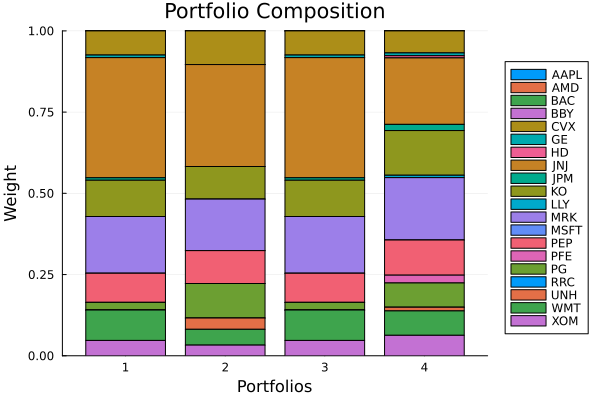

In [9]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_bench, res_nco, res_stk, res_ssr], rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*